# Algoritmo de Detección de Fuego NOAA/GOES (Fase 1)

Este cuaderno implementa de manera interactiva la **Fase 1** del algoritmo de detección sub-píxel de fuego con datos del sensor ABI (Advanced Baseline Imager) a bordo de los satélites GOES-R, basándose en el documento oficial *Algorithm Theoretical Basis Document (ATBD)*.

En esta fase exploraremos desde la carga y conversión de las temperaturas de brillo hasta la generación de las máscaras de salida que identifican píxeles con potencial fuego.

## 1. Importación de Librerías y Constantes Globales

El ATBD define valores de saturación, valores faltantes y coeficientes específicos del instrumento ABI para las funciones de Planck.

* **FPT (Focal Plane Temperature) Threshold:** Si la temperatura del plano focal excede los 90 K, el algoritmo crea una banda híbrida de onda larga para mitigar problemas.
* **Buffer de Saturación:** Un píxel se considera erróneo si su temperatura excede en 5 K la temperatura de saturación definida por el sistema.

In [1]:
import numpy as np
def obtener_mascara_noaa_colab(timestamp_str: str, region_cfg: dict, satellite: str = "G16") -> np.ndarray:
    """
    Descarga el producto oficial ABI-L2-FDCF (Fire Mask) vía goes2go,
    aplica el recorte geográfico exacto y devuelve la matriz categórica de fuegos.
    """
    dt = pd.to_datetime(timestamp_str)
    print(f"🔍 Buscando Máscara Oficial NOAA (ABI-L2-FDCF) para {timestamp_str}...")
    
    # En L2 no se especifica el parámetro 'bands'
    g = GOES(satellite=satellite, product="ABI-L2-FDCF", domain="F")
    
    files_df = g.nearesttime(dt, return_as="filelist")
    if files_df is None or len(files_df) == 0:
        raise RuntimeError(f"No se encontraron archivos L2 FDC para la fecha {timestamp_str}")
        
    relative_path = files_df.iloc[0]["file"]
    try:
        from goes2go.config import config as g2g_config
        cache_dir = g2g_config.get("default", {}).get("save_dir", os.path.expanduser("~/data"))
    except Exception:
        cache_dir = os.path.expanduser("~/data")
        
    full_path = os.path.join(cache_dir, relative_path)
    
    # Abrimos de forma diferida y recortamos usando tus slices originales
    with xr.open_dataset(full_path, engine="h5netcdf") as ds:
        xs, ys = goes_xy_slices(ds, **region_cfg)
        # La variable estándar del producto FDC de la NOAA es 'Mask'
        mask_noaa = ds.sel(x=xs, y=ys)["Mask"].values.astype(np.int16)
        
    print(f" ✅ Máscara oficial NOAA descargada con éxito. Matriz shape: {mask_noaa.shape}")
    return mask_noaa

In [2]:
from __future__ import annotations

import logging
import os
from typing import Optional

import numpy as np

# Configuración básica de logs para el entorno Colab
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

# ══════════════════════════════════════════════════════════════════════════════
# Constantes globales
# ══════════════════════════════════════════════════════════════════════════════

BR_TEMP_MISS_VAL: float = -999.0   # Valor centinela de temperatura de brillo faltante
SAT_TEMP: float         = 335.0    # Temperatura de saturación del sensor (K)
SAT_BUFF: float         = 5.0      # Buffer de saturación (K)
FPT_THRESHOLD: float    = 90.0     # Umbral de temperatura del plano focal

# Constantes de Planck para cada banda ABI usada
# Basadas en los coeficientes espectrales del ABI (GOES-R PUG L1b Rev 2)
# c1 = 2*h*c^2  [mW / (m^2·sr·cm^-4)]
# c2 = h*c/k    [K·cm]
_ABI_BAND_PARAMS: dict[int, dict[str, float]] = {
    7:  {"fk1": 202526.8, "fk2": 3698.03, "bc1": 0.4759,  "bc2": 0.99810},
    13: {"fk1": 671922.5, "fk2": 1285.62, "bc1": 0.3764,  "bc2": 0.99891},
    14: {"fk1": 620818.5, "fk2": 1216.99, "bc1": 0.3572,  "bc2": 0.99912},
    15: {"fk1": 520364.0, "fk2": 1107.43, "bc1": 0.3011,  "bc2": 0.99933},
}

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Funciones auxiliares de radiometría (Planck)
# ══════════════════════════════════════════════════════════════════════════════

def _rad_from_temp(band: int, temp: np.ndarray | float) -> np.ndarray | float:
    """
    Temperatura de brillo → radianza equivalente para *band*.
    Usa la función de Planck inversa con los coeficientes del ABI.
    """
    p   = _ABI_BAND_PARAMS[band]
    t   = (temp - p["bc1"]) / p["bc2"]
    # Evitar división por cero / overflow en exp
    t   = np.where(t > 0, t, np.nan) if isinstance(t, np.ndarray) else max(t, 1e-6)
    rad = p["fk1"] / (np.exp(p["fk2"] / t) - 1.0)
    return rad

def _temp_from_rad(band: int, rad: np.ndarray | float) -> np.ndarray | float:
    """
    Radianza → temperatura de brillo equivalente para *band*.
    """
    p    = _ABI_BAND_PARAMS[band]
    safe = np.where(rad > 0, rad, np.nan) if isinstance(rad, np.ndarray) else max(rad, 1e-12)
    t    = p["fk2"] / np.log(p["fk1"] / safe + 1.0)
    return p["bc1"] + p["bc2"] * t

def temp_to_rad(src_band: int, dst_band: int, temp: np.ndarray | float) -> np.ndarray | float:
    """
    Dada una temperatura de brillo en src_band, calcula la radianza
    equivalente en dst_band mediante la función de Planck.
    """
    rad_src = _rad_from_temp(src_band, temp)
    if src_band == dst_band:
        return rad_src
    return _rad_from_temp(dst_band, temp)

def rad_to_temp(src_band: int, dst_band: int, rad: np.ndarray | float) -> np.ndarray | float:
    """
    Dada una radianza en src_band, devuelve la temperatura de brillo
    equivalente en dst_band.
    """
    temp_src = _temp_from_rad(src_band, rad)
    if src_band == dst_band:
        return temp_src
    return _temp_from_rad(dst_band, _rad_from_temp(src_band, temp_src))

In [4]:
def _compute_pixel_area(
    range: np.ndarray, #En dónde computar el área
    latitudes: np.ndarray,
    longitudes: np.ndarray,
) -> np.ndarray:
    """
    Pixel area in km² using the 4×4 box great-circle method (ATBD 3.4.2.10).

    Corners at (i±2, j±2), distances divided by 4 before area calculation.
    Heron's formula for the parallelogram.
    """
    L, W = latitudes.shape
    index = np.argwhere(range)

    areas = np.zeros_like(latitudes)

    def _clamp(v, lo, hi):
        return max(lo, min(hi, v))
    
    def great_circle_km(r1, c1, r2, c2):
        lat1 = np.radians(latitudes [r1, c1])
        lat2 = np.radians(latitudes [r2, c2])
        lon1 = np.radians(longitudes[r1, c1])
        lon2 = np.radians(longitudes[r2, c2])
        arg  = (np.sin(lat1)*np.sin(lat2)
                + np.cos(lat1)*np.cos(lat2)*np.cos(abs(lon2-lon1)))
        arg  = np.clip(arg, -1.0, 1.0)
        return 6378.137 * np.arccos(arg)

    for (i,j) in index:
        c = [
            (_clamp(i-2, 0, L-1), _clamp(j-2, 0, W-1)),
            (_clamp(i+2, 0, L-1), _clamp(j-2, 0, W-1)),
            (_clamp(i+2, 0, L-1), _clamp(j+2, 0, W-1)),
            (_clamp(i-2, 0, L-1), _clamp(j+2, 0, W-1)),
        ]

    
        # Sides of the 4×4 box divided by 4
        a = great_circle_km(*c[0], *c[1]) / 4.0   # top-left → bottom-left
        b = great_circle_km(*c[1], *c[2]) / 4.0   # bottom-left → bottom-right
        d = great_circle_km(*c[0], *c[2]) / 4.0   # diagonal (used in Heron)

        # Heron for one triangle × 2 → parallelogram area
        s = (a + b + d) / 2.0
        try:
            area = 2.0 * np.sqrt(max(0.0, s * (s-a) * (s-b) * (s-d)))
        except Exception:
            area = 0.0
        areas[i,j] = area 

    return areas

## 7. Adquisición y Recorte de Datos mediante `goes2go` y visualizacion inicial

En lugar de descargar discos completos (*Full Disk*) en bruto que saturen la memoria de la máquina virtual de Colab, adaptaremos el script operativo del pipeline `downloader.py`. 

Este método utiliza `goes2go` para localizar el archivo en los servidores de la NOAA, lo abre en modo diferido (*lazy*) con `xarray` y realiza un recorte espacial exacto convirtiendo límites de Latitud/Longitud a coordenadas de proyección geoestacionaria ($x, y$).

Definiremos los límites geográficos para **Uruguay** y configuraremos los parámetros para las bandas térmicas 7 (3.9 µm), 13 (10.3 µm) y 14 (11.2 µm).

💡 Sugerencia de mejora para tu PFC / Colab:
En el script original fire_detection.py, estos filtros rápidos se ejecutan dentro de un bucle anidado for i in range(L): for j in range(W): píxel por píxel. En Python, realizar bucles de más de 5000x5000 elementos es extremadamente lento.

Al estructurar esta parte en el Colab usando operaciones vectoriales de NumPy (np.where), el procesamiento de estos descartes iniciales va a pasar de tardar varios minutos a ejecutarse en milisegundos. Esto te va a permitir visualizar máscaras intermedias súper rápido usando plt.imshow().

In [ ]:
# Instalar dependencias necesarias para este bloque si no están
#!pip install goes2go pyproj netCDF4 h5netcdf matplotlib

import os
import numpy as np
import pyproj
import xarray as xr
import pandas as pd
from goes2go import GOES
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# 1. Configuraciones de Región (Uruguay) y Productos ABI
# ══════════════════════════════════════════════════════════════════════════════

# Caja de recorte para Uruguay
REGION_URUGUAY = {
    "lat_min": -35.5,
    "lat_max": -30.0,
    "lon_min": -58.5,
    "lon_max": -53.0
}

# Configuraciones de las bandas requeridas por el algoritmo
PRODUCTOS_ABI = { 
    1: {"id": "ABI-L1b-B01", "product": "ABI-L1b-RadF", "band": 1,  "variable": "Rad"},
    2: {"id": "ABI-L1b-B02", "product": "ABI-L1b-RadF", "band": 2,  "variable": "Rad"},
    3: {"id": "ABI-L1b-B03", "product": "ABI-L1b-RadF", "band": 3,  "variable": "Rad"},
    4: {"id": "ABI-L1b-B03", "product": "ABI-L1b-RadF", "band": 4,  "variable": "Rad"},
    5: {"id": "ABI-L1b-B03", "product": "ABI-L1b-RadF", "band": 5,  "variable": "Rad"},
    6: {"id": "ABI-L1b-B03", "product": "ABI-L1b-RadF", "band": 6,  "variable": "Rad"},
    7: {"id": "ABI-L1b-B07", "product": "ABI-L1b-RadF", "band": 7,  "variable": "Rad"},
    8: {"id": "ABI-L1b-B03", "product": "ABI-L1b-RadF", "band": 8,  "variable": "Rad"},
    9: {"id": "ABI-L1b-B03", "product": "ABI-L1b-RadF", "band": 9,  "variable": "Rad"},
    10: {"id": "ABI-L1b-B03", "product": "ABI-L1b-RadF", "band": 10,  "variable": "Rad"},
    11: {"id": "ABI-L1b-B03", "product": "ABI-L1b-RadF", "band": 11,  "variable": "Rad"},
    12: {"id": "ABI-L1b-B03", "product": "ABI-L1b-RadF", "band": 12,  "variable": "Rad"},
    13: {"id": "ABI-L1b-B13", "product": "ABI-L1b-RadF", "band": 13, "variable": "Rad"},
    14: {"id": "ABI-L1b-B14", "product": "ABI-L1b-RadF", "band": 14, "variable": "Rad"},
    15: {"id": "ABI-L1b-B15", "product": "ABI-L1b-RadF", "band": 15, "variable": "Rad"},

}

# ══════════════════════════════════════════════════════════════════════════════
# 2. Funciones de Transformación de Coordenadas (script original)
# ══════════════════════════════════════════════════════════════════════════════

def goes_xy_slices(ds, lat_min, lat_max, lon_min, lon_max):
    """Convierte un bounding box de lat/lon a slices de índices x/y de GOES."""
    proj_info  = ds["goes_imager_projection"]
    lon_origin = float(proj_info.longitude_of_projection_origin)
    H          = float(proj_info.perspective_point_height) + float(proj_info.semi_major_axis)

    crs_goes = pyproj.CRS.from_dict({
        "proj": "geos", "lon_0": lon_origin,
        "h": float(proj_info.perspective_point_height),
        "a": float(proj_info.semi_major_axis),
        "b": float(proj_info.semi_minor_axis),
        "sweep": "x",
    })
    transformer = pyproj.Transformer.from_crs(
        pyproj.CRS.from_epsg(4326), crs_goes, always_xy=True
    )
    px, py = transformer.transform(
        [lon_min, lon_max, lon_min, lon_max],
        [lat_min, lat_min, lat_max, lat_max],
    )
    x_vals, y_vals = ds["x"].values, ds["y"].values
    x_slice = slice(
        float(x_vals[np.argmin(np.abs(x_vals - np.nanmin(px) / H))]),
        float(x_vals[np.argmin(np.abs(x_vals - np.nanmax(px) / H))]),
    )
    y_slice = slice(
        float(y_vals[np.argmin(np.abs(y_vals - np.nanmax(py) / H))]),
        float(y_vals[np.argmin(np.abs(y_vals - np.nanmin(py) / H))]),
    )
    return x_slice, y_slice


# ══════════════════════════════════════════════════════════════════════════════
# 3. Función Modular de Descarga y Extracción de Radianzas + Temp de Brillo
# ══════════════════════════════════════════════════════════════════════════════

import os
import pandas as pd
import numpy as np
import xarray as xr
from goes2go import GOES
import time

def obtener_datos_banda_colab(timestamp_str: str, banda: int, region_cfg: dict, satellite: str = "G19") -> tuple[np.ndarray, np.ndarray]:
    """
    Descarga vía goes2go para GOES-19 por defecto, abre de forma lazy, 
    recorta sobre Uruguay y calcula la Temperatura de Brillo.
    """
    dt = pd.to_datetime(timestamp_str)
    p_cfg = PRODUCTOS_ABI[banda]
    
    print(f"🔍 [GOES-19] Buscando {p_cfg['id']} para la fecha {timestamp_str}...")
    
    # Inicialización limpia para GOES-19
    g = GOES(satellite=satellite, product=p_cfg["product"], domain="F", bands=p_cfg["band"])
    
    #print(g.latest())
    #print("GOES creado")

    files_df = g.nearesttime(dt, return_as="filelist")

    #print("Luego de nearesttime")

    if files_df is None or len(files_df) == 0:
        raise RuntimeError(f"No se encontraron archivos en AWS para GOES-19, banda {banda} en {timestamp_str}")
    
    
    relative_path = files_df.iloc[0]["file"]
    try:
        from goes2go.config import config as g2g_config
        cache_dir = g2g_config.get("default", {}).get("save_dir", os.path.expanduser("~/data"))
    except Exception:
        cache_dir = os.path.expanduser("~/data")
        
    full_path = os.path.join(cache_dir, relative_path)
    
    with xr.open_dataset(full_path, engine="h5netcdf") as ds:
        #print(ds)
        xs, ys = goes_xy_slices(ds, **region_cfg)
        ds_cropped = ds.sel(x=xs, y=ys)
        
        rad = ds_cropped[p_cfg["variable"]].values.astype(np.float32)
        
        # Constantes escalares extraídas de forma segura con .item()
        fk1 = float(ds_cropped['planck_fk1'].item())
        fk2 = float(ds_cropped['planck_fk2'].item())
        bc1 = float(ds_cropped['planck_bc1'].item())
        bc2 = float(ds_cropped['planck_bc2'].item())
        
        rad_safe = np.where(rad > 0, rad, np.nan)
        b_temp = (fk2 / np.log((fk1 / rad_safe) + 1.0) - bc1) / bc2
        b_temp = np.where(np.isnan(b_temp), -999.0, b_temp)
        
    print(f" ✅ GOES-19 B{banda:02d} descargada y recortada. Shape: {rad.shape}")
    return b_temp.astype(np.float32), rad


def obtener_mascara_noaa_colab(timestamp_str: str, region_cfg: dict, satellite: str = "G19") -> np.ndarray:
    """
    Descarga el producto oficial de fuegos ABI-L2-FDCF para GOES-19,
    aplica el recorte geográfico exacto y devuelve la matriz Mask.
    """
    dt = pd.to_datetime(timestamp_str)
    print(f"🔍 [GOES-19] Buscando Máscara Oficial NOAA (ABI-L2-FDCF) para {timestamp_str}...")
    
    g = GOES(satellite=satellite, product="ABI-L2-FDCF", domain="F")
    
    files_df = g.nearesttime(dt, return_as="filelist")
    if files_df is None or len(files_df) == 0:
        raise RuntimeError(f"No se encontraron archivos L2 FDC en GOES-19 para la fecha {timestamp_str}")
        
    relative_path = files_df.iloc[0]["file"]
    try:
        from goes2go.config import config as g2g_config
        cache_dir = g2g_config.get("default", {}).get("save_dir", os.path.expanduser("~/data"))
    except Exception:
        cache_dir = os.path.expanduser("~/data")
        
    full_path = os.path.join(cache_dir, relative_path)
    
    with xr.open_dataset(full_path, engine="h5netcdf") as ds:
        xs, ys = goes_xy_slices(ds, **region_cfg)
        mask_noaa = ds.sel(x=xs, y=ys)["Mask"].values.astype(np.int16)
        
    print(f" ✅ Máscara oficial GOES-19 descargada con éxito. Shape: {mask_noaa.shape}")
    return mask_noaa

# Descarga de datos 

In [6]:
import os
import pandas as pd
import numpy as np
import xarray as xr
from goes2go import GOES
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pyproj as Proj

In [33]:
fecha_test = "2025-11-15"
hora_ini = "12:00"
hora_fin = "20:00"
fecha_ini = fecha_test + " " + hora_ini 
fecha_fin = fecha_test + " " + hora_fin

In [34]:
time_step = 10 #En minutos
#Tomar fechas cada time_step minutos
fechas = pd.date_range(
    start=fecha_ini,
    end=fecha_fin,
    freq=f"{time_step}min"
)
print(fechas)

DatetimeIndex(['2025-11-15 12:00:00', '2025-11-15 12:10:00',
               '2025-11-15 12:20:00', '2025-11-15 12:30:00',
               '2025-11-15 12:40:00', '2025-11-15 12:50:00',
               '2025-11-15 13:00:00', '2025-11-15 13:10:00',
               '2025-11-15 13:20:00', '2025-11-15 13:30:00',
               '2025-11-15 13:40:00', '2025-11-15 13:50:00',
               '2025-11-15 14:00:00', '2025-11-15 14:10:00',
               '2025-11-15 14:20:00', '2025-11-15 14:30:00',
               '2025-11-15 14:40:00', '2025-11-15 14:50:00',
               '2025-11-15 15:00:00', '2025-11-15 15:10:00',
               '2025-11-15 15:20:00', '2025-11-15 15:30:00',
               '2025-11-15 15:40:00', '2025-11-15 15:50:00',
               '2025-11-15 16:00:00', '2025-11-15 16:10:00',
               '2025-11-15 16:20:00', '2025-11-15 16:30:00',
               '2025-11-15 16:40:00', '2025-11-15 16:50:00',
               '2025-11-15 17:00:00', '2025-11-15 17:10:00',
               '2025-11-

Obtener bandas 7 y 14

In [35]:
band7 = []
band14 = []
for f in fechas:
    bTemp7_uy, rad7_uy   = obtener_datos_banda_colab(f, 7, REGION_URUGUAY)
    bTemp14_uy, rad14_uy = obtener_datos_banda_colab(f, 14, REGION_URUGUAY)
    band7.append(bTemp7_uy)
    band14.append(bTemp14_uy)
    
print(np.array(band7).shape)

🔍 [GOES-19] Buscando ABI-L1b-B07 para la fecha 2025-11-15 12:00:00...
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L1b-RadF].
<xarray.Dataset> Size: 235MB
Dimensions:                                           (y: 5424, x: 5424,
                                                       number_of_time_bounds: 2,
                                                       number_of_image_bounds: 2,
                                                       number_of_harmonization_coefficients: 3,
                                                       num_star_looks: 24,
                                                       band: 1)
Coordinates:
  * y                                                 (y) float32 22kB 0.1518...
  * x                                                 (x) float32 22kB -0.151...
    t_star_look                                       (num_star_looks) datetime64[ns] 192B ...
    band_wavelength_star_look                         (num_star_looks) float

Obtener fire hotspots

In [36]:
fire_masks = []
for f in fechas:
    mascara_noaa_uy = obtener_mascara_noaa_colab(f, REGION_URUGUAY)
    #Quedarse solo con los codigos relevantes (por ej los de incendios)
    fire_masks.append(mascara_noaa_uy)


🔍 [GOES-19] Buscando Máscara Oficial NOAA (ABI-L2-FDCF) para 2025-11-15 12:00:00...
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L2-FDCF].
 ✅ Máscara oficial GOES-19 descargada con éxito. Shape: (203, 246)
🔍 [GOES-19] Buscando Máscara Oficial NOAA (ABI-L2-FDCF) para 2025-11-15 12:10:00...
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L2-FDCF].
 ✅ Máscara oficial GOES-19 descargada con éxito. Shape: (203, 246)
🔍 [GOES-19] Buscando Máscara Oficial NOAA (ABI-L2-FDCF) para 2025-11-15 12:20:00...
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L2-FDCF].
 ✅ Máscara oficial GOES-19 descargada con éxito. Shape: (203, 246)
🔍 [GOES-19] Buscando Máscara Oficial NOAA (ABI-L2-FDCF) para 2025-11-15 12:30:00...
📦 Finished downloading [1] files to [C:\Users\pedro\data\noaa-goes19\ABI-L2-FDCF].
 ✅ Máscara oficial GOES-19 descargada con éxito. Shape: (203, 246)
🔍 [GOES-19] Buscando Máscara Oficial NOAA (ABI-L2-FDCF) para 202

# Preprocesamiento

Cálculo de índices auxiliares

In [10]:
#Normalized Difference Vegetation Index (vegetación)
def ndvi_abi(band2_reflectance: np.ndarray, band3_reflectance: np.ndarray) -> np.ndarray:
    return (band3_reflectance- band2_reflectance)/(band3_reflectance+band2_reflectance)
#Normalized Burn Ratio (daño por fuego)
def nbr_abi(band3_reflectance: np.ndarray, band6_reflectance: np.ndarray) -> np.ndarray:
    return (band3_reflectance-band6_reflectance)/(band3_reflectance+band6_reflectance)
#Normalized Difference Moisture Index (Agua en vegetación)
def ndmi_ani(band3_reflectance: np.ndarray, band5_reflectance: np.ndarray) -> np.ndarray:
    return (band3_reflectance-band5_reflectance)/(band3_reflectance+band5_reflectance)

In [28]:
ndvi, nbr, ndmi = [],[],[]


Dividir las imágenes en parches

In [11]:
def get_patches(img: np.ndarray, patch_size = 64, stride = 32):
    ''' 
    Divide la imagen de entrada en parches de tamaño patch_size x patch_size.
    '''
    patches = []; coords = []
    H,W = img.shape 
    for y in range(0,H-patch_size+1,stride):
        for x in range(0,W-patch_size+1,stride):
            patch = img[y:y+patch_size,x:x+patch_size]
            patches.append(patch)
            coords.append((y,x))
    return patches, coords

In [12]:
fire_codes = (13,14,15)
def get_labels(coords,fire_mask,patch_size = 64):
    labels = []
    for y,x in coords:
        patch_fire = fire_mask[y:y+patch_size,x:x+patch_size]
        #label = np.any(patch_fire in fire_codes) 
        labels.append(patch_fire)
    return labels

In [13]:
patches, coords = get_patches(band7[0])
print(len(patches))

30


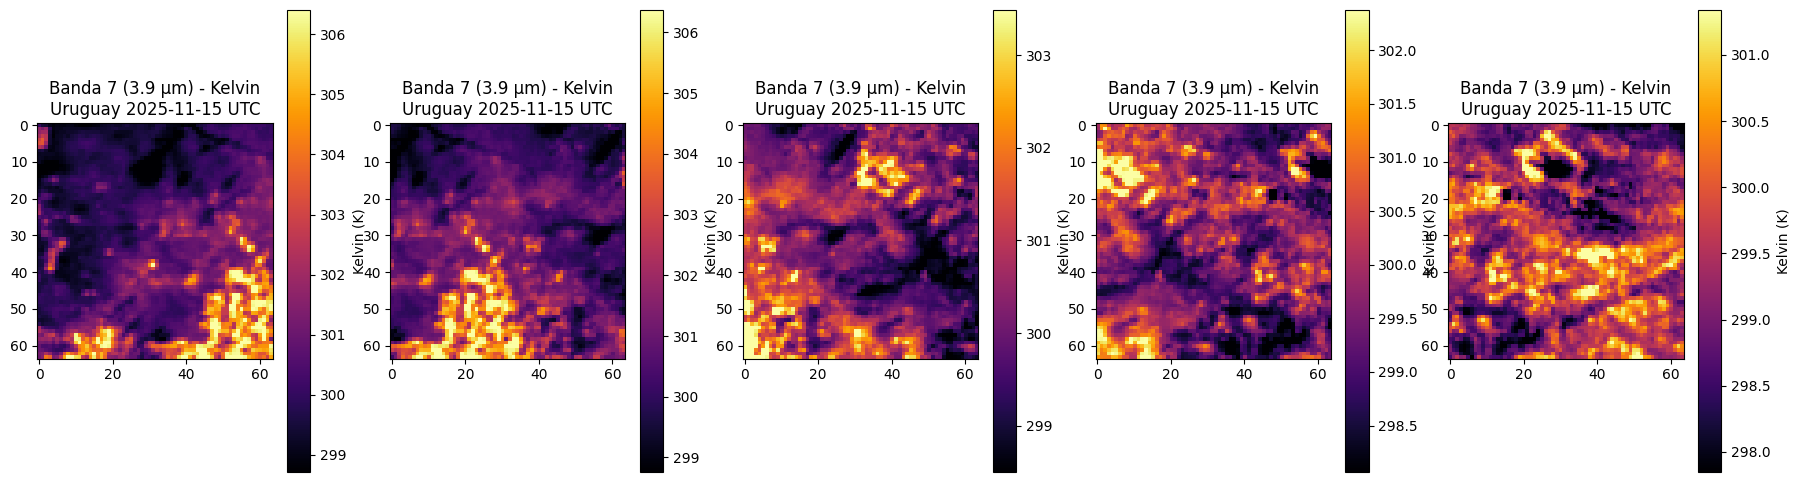

In [14]:
n_patches = len(patches)
fig, ax = plt.subplots(1, 5, figsize=(22, 6))
for i in range(5):
    p = patches[i]
    vmin = np.percentile(p, 2)
    vmax = np.percentile(p, 98)

    # Panel 1: Infrarrojo de Onda Corta
    im1 = ax[i].imshow(p, cmap='inferno', vmin=vmin, vmax=vmax)
    ax[i].set_title(f"Banda 7 (3.9 µm) - Kelvin\nUruguay {fecha_test} UTC")
    fig.colorbar(im1, ax=ax[i], label="Kelvin (K)")

Armar una secuencia temporal de imágenes para los parches

# Creación de dataset

In [37]:
n_bands  = 2 #Cantidad de bandas
all_patches7 = []
all_patches14 = []
all_patches_fire = []

for i in range(len(fechas)):
    #Divido cada banda en parches
    patches7, coords = get_patches(band7[i])
    patches14, _ = get_patches(band14[i])
    labels = get_labels(coords,fire_masks[i])
    all_patches7.append(patches7) ; all_patches14.append(patches14) ; all_patches_fire.append(labels)

#Cada columna del array (TxN) es una secuencia
all_patches7 = np.stack(all_patches7, axis=0)
all_patches14 = np.stack(all_patches14, axis=0)
all_patches_fire = np.stack(all_patches_fire, axis=0)

#Deberia ser (n_t,n_p,h,w) donde n_t es la cant de tiempos, n_p la cant de parches por imagen y hxw tamaño de parche
print(all_patches7.shape)
print(all_patches14.shape)
print(all_patches_fire.shape)

(49, 30, 64, 64)
(49, 30, 64, 64)
(49, 30, 64, 64)


Construyo una serie temporal para cada parche

In [38]:
history = 12 #Imágenes previas
lead_time = 3

print("Historia de "+str(history*time_step)+" minutos")
print("Predicción para dentro de "+str(lead_time*time_step)+" minutos")

Historia de 120 minutos
Predicción para dentro de 30 minutos


In [39]:
n_patches = all_patches7.shape[1] #Cantidad de fechas
X = []
y = []
for i in range(n_patches):
    seq7 = all_patches7[:,i,:,:] #Tomo una columna, que corresponde a todos los tiempos para el parche i-ésimo
    seq14 = all_patches14[:,i,:,:]
    seq_fire = all_patches_fire[:,i,:,:]
    
    max_t = len(fechas) - history - lead_time

    for t in range(max_t): #Creo muestras con history tiempos para las cuales tenga una mascara lead_time tiempos despues
        x = np.stack([seq7[t:t+history],seq14[t:t+history]],axis=-1) # cantidad de timestamps = history 
        future_fire_mask = seq_fire[t+history+lead_time] #Mascara lead_time timestamps después

        target = np.isin(future_fire_mask,[13,14,15]).any() #Si se quiere directamente predecir la mascara, entonces hacer target = future_fire_mask

        X.append(x)
        y.append(int(target))

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print(X.shape)
print(y.shape)

(1020, 12, 64, 64, 2)
(1020,)


In [50]:
print(y)
print(np.mean(y)*100)
print(np.sum(y))

[1 0 0 ... 1 0 0]
4.509803921568627
46



# Información mutua

In [51]:
from sklearn.feature_selection import mutual_info_classif

lags = tuple(range(history))

lead_time = 1

mis = []

for lag in lags:
    X_lag = []
    Y = []
    for p in range(n_patches):
        seq7 = all_patches7[:,p]
        seq14 = all_patches14[:,p]
        seq_fire = all_patches_fire[:,p]

        for t in range(lag,len(fechas)-lead_time):
            patch = seq7[t-lag] - seq14[t-lag]
            X_lag.append(
                [patch.mean(),
                  patch.std(),
                  patch.max(),
                  patch.min(),
                  np.percentile(patch, 95),
                  np.percentile(patch, 99),
                  patch.max() - patch.mean()
                ]
                )
            
            future = (seq_fire[t+lead_time])
            Y.append(np.isin(future,[13,14,15]).any())


    mi = mutual_info_classif(
        np.array(X_lag),
        np.array(Y),
        random_state=42
    )
    mis.append(mi)

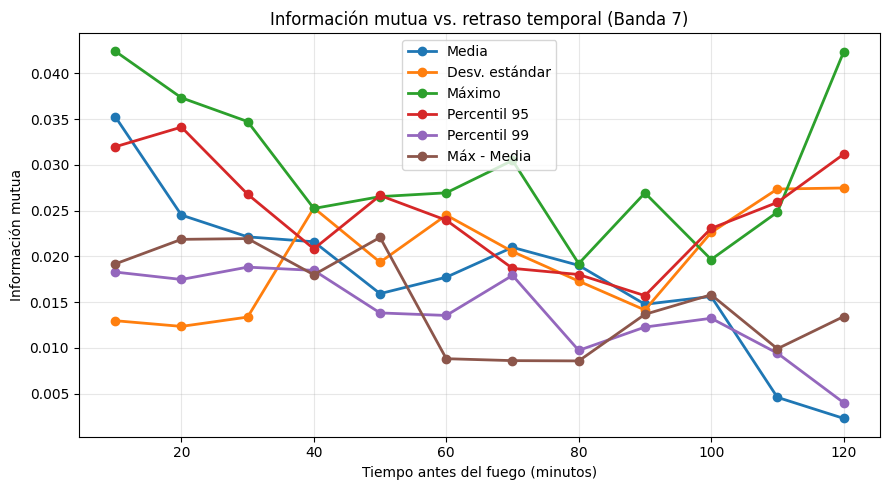

In [52]:

mis = np.array(mis)

lags = np.arange(history) * time_step
lags_min = (np.arange(history) + lead_time) * time_step

feature_names = [
    "Media",
    "Desv. estándar",
    "Máximo",
    "Percentil 95",
    "Percentil 99",
    "Máx - Media"
]

plt.figure(figsize=(9,5))

for i, name in enumerate(feature_names):
    plt.plot(
        lags_min,
        mis[:, i],
        marker='o',
        linewidth=2,
        label=name
    )

plt.xlabel("Tiempo antes del fuego (minutos)")
plt.ylabel("Información mutua")
plt.title("Información mutua vs. retraso temporal (Banda 7)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

In [44]:
max_lead = 12
leads = range(max_lead + 1)   # e.g. if 10 min cadence:
                              # max_lead=6 -> 0,10,...,60 min

mis = []

for lead in leads:

    X = []
    Y = []

    for p in range(n_patches):

        seq7 = all_patches7[:, p]
        seq14 = all_patches14[:, p]
        seq_fire = all_patches_fire[:, p]

        for t in range(len(fechas) - lead):

            # current image (lag = 0)
            patch = seq7[t] - seq14[t]

            X.append([
                patch.mean(),
                patch.std(),
                patch.max(),
                np.percentile(patch, 95),
                np.percentile(patch, 99),
                patch.max() - patch.mean()
            ])

            future = seq_fire[t + lead]

            Y.append(np.isin(future, [13, 14, 15]).any())

    mi = mutual_info_classif(
        np.asarray(X),
        np.asarray(Y),
        random_state=42
    )

    mis.append(mi)

mis = np.array(mis)

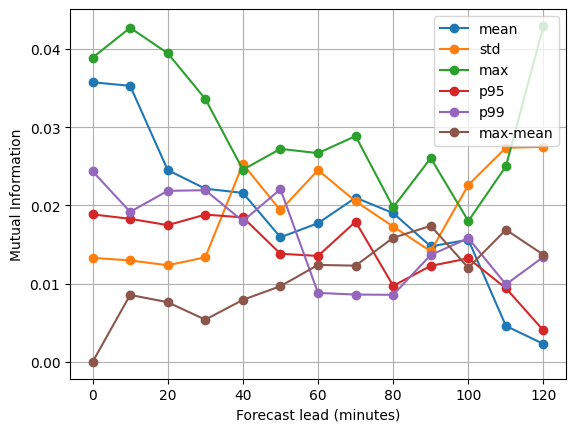

In [48]:
feature_names = [
    "mean",
    "std",
    "max",
    "p95",
    "p99",
    "max-mean",
]

lead_minutes = np.array(list(leads)) * 10   # if images are every 10 min

for i, name in enumerate(feature_names):
    plt.plot(lead_minutes, mis[:, i], marker="o", label=name)

plt.xlabel("Forecast lead (minutes)")
plt.ylabel("Mutual Information")
plt.legend()
plt.grid(True)

In [56]:
X = np.asarray(X)
Y = np.asarray(Y)

mi_real = mutual_info_classif(
    X, Y, random_state=42
)

mi_shuffle = []

for i in range(50):
    Y_perm = np.random.permutation(Y)

    mi = mutual_info_classif(
        X,
        Y_perm,
        random_state=i
    )

    mi_shuffle.append(mi)

mi_shuffle = np.array(mi_shuffle)

print("real:", mi_real)
print("shuffle mean:", mi_shuffle.mean(axis=0))
print("shuffle std:", mi_shuffle.std(axis=0))
print("z-score",(mi_real - mi_shuffle.mean(axis=0))/mi_shuffle.std(axis=0))

real: [0.00475788 0.03449511 0.03438688 0.00697608 0.01397485 0.01381045]
shuffle mean: [0.00233038 0.00195178 0.00302657 0.00235308 0.00382969 0.00197999]
shuffle std: [0.00386577 0.0035629  0.00366877 0.00335997 0.00410089 0.00313549]
z-score [0.62794903 9.13393224 8.5479123  1.37590636 2.47389352 3.77308478]


In [54]:
max_lead = 12
leads = range(max_lead + 1)   # e.g. if 10 min cadence:
                              # max_lead=6 -> 0,10,...,60 min

mis = []

for lead in leads:

    X = []
    Y = []

    for p in range(n_patches):

        seq7 = all_patches7[:, p]
        seq14 = all_patches14[:, p]
        seq_fire = all_patches_fire[:, p]

        for t in range(len(fechas) - lead):

            # current image (lag = 0)
            patch = seq7[t] - seq14[t]

            X.append([
                patch.mean(),
                patch.std(),
                patch.max(),
                np.percentile(patch, 95),
                np.percentile(patch, 99),
                patch.max() - patch.mean()
            ])

            future = seq_fire[t + lead]

            Y.append(np.isin(future,[13,14,15]).sum()) #Sum en vez de any

    mi = mutual_info_classif(
        np.asarray(X),
        np.asarray(Y),
        random_state=42
    )

    mis.append(mi)

mis = np.array(mis)

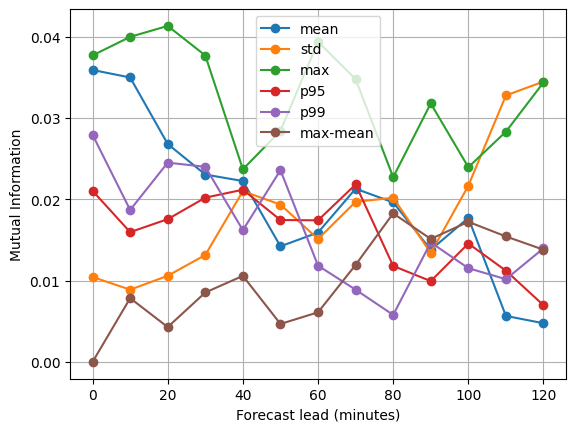

In [55]:
feature_names = [
    "mean",
    "std",
    "max",
    "p95",
    "p99",
    "max-mean",
]

lead_minutes = np.array(list(leads)) * 10   # if images are every 10 min

for i, name in enumerate(feature_names):
    plt.plot(lead_minutes, mis[:, i], marker="o", label=name)

plt.xlabel("Forecast lead (minutes)")
plt.ylabel("Mutual Information")
plt.legend()
plt.grid(True)

# ConvLSTM

In [ ]:
class ConvLSTMCell(nn.Module):

    def __init__(self,input_dim,hidden_dim,kernel_size=3):
        super().__init__()

        padding = kernel_size // 3

        self.hidden_dim = hidden_dim

        self.conv = nn.Conv2d(input_dim + hidden_dim, 4*hidden_dim , kernel_size,padding = padding)
    
    def forward(self,x,h,c):
        combined = torch.cat([x,h],dim=1)
        gates = self.conv(combined)
        i,f,o,g = torch.chunk(gates,4,dim=1) #input, forget, output

        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.sigmoid(g)

        c_next = f*c+i*g #cell state
        h_next = o*torch.tanh(c_next) #hidden state

        return h_next,c_next

In [44]:
class ConvLSTM(nn.Module):

    def __init__(self, input_dim, hidden_dim):
        super().__init__()

        self.hidden_dim = hidden_dim

        self.cell = ConvLSTMCell(
            input_dim=input_dim,
            hidden_dim=hidden_dim
        )

    def forward(self, x):

        B, T, C, H, W = x.shape

        h = torch.zeros(
            B,
            self.hidden_dim,
            H,
            W,
            device=x.device
        )

        c = torch.zeros_like(h)

        for t in range(T):

            h, c = self.cell(
                x[:, t],
                h,
                c
            )

        return h

In [ ]:
class FireForecastModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.convlstm = ConvLSTM(
            input_dim=2,      # Band 7 + Band 14
            hidden_dim=32
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Linear(32, 1)

    def forward(self, x):

        h = self.convlstm(x)

        h = self.pool(h)

        h = h.squeeze(-1).squeeze(-1)

        out = self.fc(h)

        return out

Con encoder

In [46]:
class Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(
                in_channels=2,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool2d(2)

        )

    def forward(self, x):

        return self.encoder(x)

class FireForecastModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = Encoder()

        self.convlstm = ConvLSTM(
            input_dim=32,
            hidden_dim=64
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Linear(64, 1)

    def forward(self, x):

        B, T, C, H, W = x.shape

        # Encode every frame
        x = x.reshape(B*T, C, H, W)

        x = self.encoder(x)

        _, C2, H2, W2 = x.shape

        x = x.reshape(
            B,
            T,
            C2,
            H2,
            W2
        )

        # Temporal modeling
        h = self.convlstm(x)

        # Global pooling
        h = self.pool(h)

        h = h.flatten(1)

        logits = self.fc(h)

        return logits

# Entrenamiento

In [48]:
print(torch.cuda.is_available())

False


In [47]:
model = FireForecastModel().cuda()

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

AssertionError: Torch not compiled with CUDA enabled

In [ ]:
for X_batch, y_batch in train_loader:

    X_batch = X_batch.cuda()

    y_batch = y_batch.float().cuda()

    logits = model(X_batch).squeeze()

    loss = criterion(logits, y_batch)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

In [ ]:
probs = torch.sigmoid(logits)

# Paper modelo regresion

Ignorar por ahora...

In [7]:
def obtener_datos_reflectancia_colab(timestamp_str: str, banda: int, region_cfg: dict, satellite: str = "G19") -> tuple[np.ndarray, np.ndarray]:

    dt = pd.to_datetime(timestamp_str)
    p_cfg = PRODUCTOS_ABI[banda]
    
    print(f"🔍 [GOES-19] Buscando {p_cfg['id']} para la fecha {timestamp_str}...")
    
    # Inicialización limpia para GOES-19
    g = GOES(satellite=satellite, product="ABI-L2-BRFF", domain="F", bands=p_cfg["band"])
    
    #print(g.latest())
    #print("GOES creado")

    files_df = g.nearesttime(dt, return_as="filelist")

    #print("Luego de nearesttime")

    if files_df is None or len(files_df) == 0:
        raise RuntimeError(f"No se encontraron archivos en AWS para GOES-19, banda {banda} en {timestamp_str}")
    
    
    relative_path = files_df.iloc[0]["file"]
    try:
        from goes2go.config import config as g2g_config
        cache_dir = g2g_config.get("default", {}).get("save_dir", os.path.expanduser("~/data"))
    except Exception:
        cache_dir = os.path.expanduser("~/data")
        
    full_path = os.path.join(cache_dir, relative_path)
    
    with xr.open_dataset(full_path, engine="h5netcdf") as ds:
        xs, ys = goes_xy_slices(ds, **region_cfg)
        ds_cropped = ds.sel(x=xs, y=ys)
        
        refl = ds_cropped[p_cfg["variable"]].values.astype(np.float32)
        
    
        
    print(f" ✅ GOES-19 B{banda:02d} descargada y recortada. Shape: {refl.shape}")
    return refl.astype(np.float32)

In [ ]:
import pandas as pd
from scipy.stats import linregress

In [ ]:
ndvi = (refl2-refl3)/(refl2+refl3)#NDVI (Normalized Difference Vegetation Index)
ndii7 = (refl3-refl6)/(refl3+refl6) #NDII7 (Normalized Difference Infrared Index)
lst = ... #ABI-L2-LSTC, Land surface temperature

In [ ]:

df = pd.DataFrame({
    "ndvi": ndvi.values.ravel(),
    "temp": temp.values.ravel()
})
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna() #Elimino filas con nan

#df = df[(df["ndvi"] > 0) & (df["ndvi"] < 1)]

df["bin"] = pd.cut(df["ndvi"], bins=50) #Divido eje ndvi en 50 bins

dry = df.groupby("bin")["temp"].quantile(0.98) #Busco pixeles mas calientes en cada bin
wet = df.groupby("bin")["temp"].quantile(0.02) #Busco pixeles mas frios en cada bin

centers = np.array([ #Centros de cada bin
    interval.mid
    for interval in dry.index.categories
])
valid = ~(np.isnan(dry.values) | np.isnan(wet.values)) #Elimino bins vacios
x = centers[valid]
dry_y = dry.values[valid]
wet_y = wet.values[valid]


dry_slope, dry_intercept, *_ = linregress(x, dry_y) #Ajusto valores mediante regresion lineal
tdry = dry_intercept + dry_slope * ndvi


wet_constant = np.nanmean(wet_y)



tvdi = (lst - wet_constant) / (tdry - wet_constant)
tvdi = tvdi.clip(min=0, max=1)

